# 3. Subplots and Combining Visualizations

### Let's learn how to: 
    1. Work with subplots in matplotlib
    2. Modify figure layout
    3. Place multiple visualizations on the same axes object
    4. Add error information to plots
    5. Add images to plots

## Work with Subplots

In [44]:
##load packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [45]:
##make sample data
np.random.seed(613)
x1 = np.arange(50)
y1 = np.random.randint(0, 75,50) ##randint(min,max,# of values)
x2 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y2 = np.array([110, 180, 240, 99, 220])

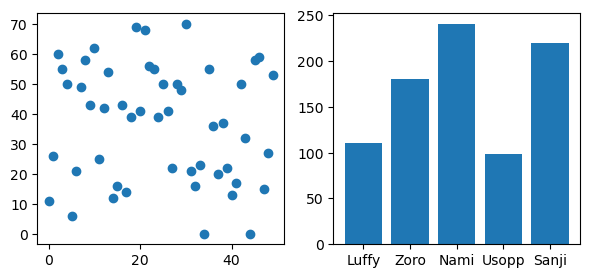

In [4]:
##Recall how figures and axes work in matplotlib [axes in figures]
##When we want to have multiple axes in our figure 
##(i.e. multiple plots next to each other) we can use subplots

##define 2 axes (ax1, ax2)
##inside the plt.subplots() specify the number of columns, number of rows
fig, (ax1, ax2) = plt.subplots(ncols=2, 
                               nrows=1, 
                               figsize=(7, 3))
ax1.scatter(x1,y1)
ax2.bar(x2,y2)
fig.show()

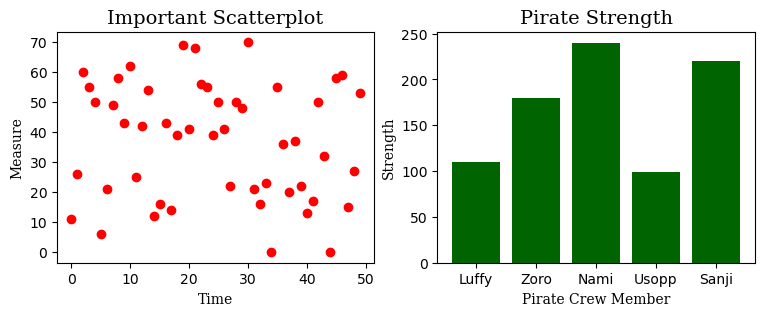

In [38]:
fig, (ax1, ax2) = plt.subplots(ncols=2, 
                               nrows=1, 
                               figsize=(9, 3))

font1 = {'family':'serif', 'size':10} ##for axis titles
font2 = {'family':'serif', 'size':14} ##for each plot title


ax1.scatter(x1,
            y1,
            marker='o', 
            color = 'red')
ax2.bar(x2,
        y2, 
        color = 'darkgreen')

##add titles and make all text serif
ax1.set_title('Important Scatterplot', fontdict=font2)
ax1.set_ylabel('Measure', fontdict=font1)
ax1.set_xlabel('Time', fontdict=font1)
ax2.set_title('Pirate Strength', fontdict=font2)
ax2.set_ylabel('Strength', fontdict=font1)
ax2.set_xlabel('Pirate Crew Member', fontdict=font1)


fig.show()

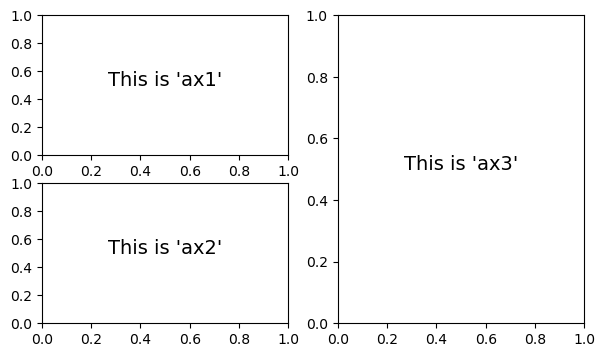

In [40]:
##If we want to get fancy with our axes (e.g. not just a grid)
##We can use plt.subplot_mosaic
##each argument in our plt.subplot_mosaic is a 'label'
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
                                ['ax2', 'ax3']],
                                figsize=(7, 4))

##now label each one
for label, ax in someaxes.items():
    ax.text(0.5, 0.5, f'This is {label!r}', 
            fontsize=14,
           ha = 'center',
           transform=ax.transAxes) ##recall: to remind matplot lib that we're referring to position relative to each axis (so in our case, the middle of each)

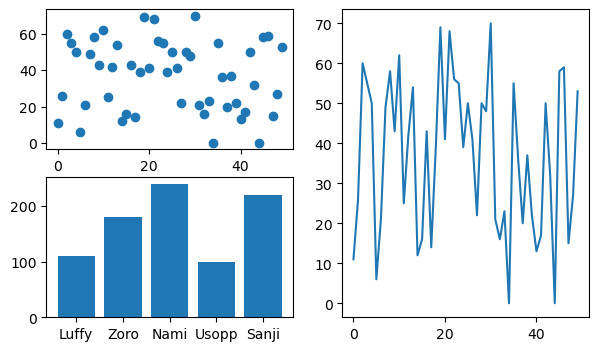

In [42]:
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
                                ['ax2', 'ax3']],
                                figsize=(7, 4))

##now let's add data to each of our subplots in our someaxes collection
##this works the exact same as how we plotted things before! just reference the axes object differently
someaxes["ax1"].scatter(x1,y1)
someaxes["ax2"].bar(x2,y2)
someaxes["ax3"].plot(x1,y1)

plt.show()


## Modify Figure Layout

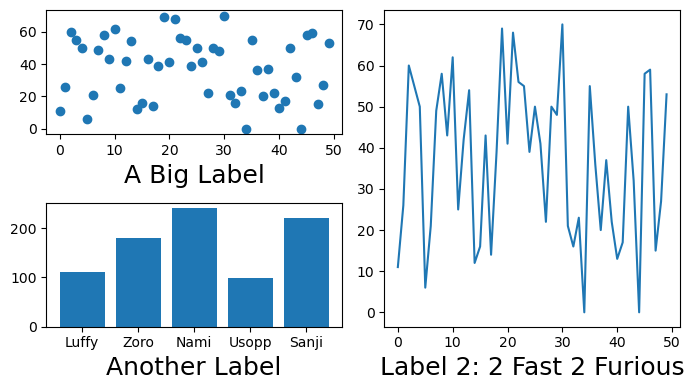

In [48]:
##You can use layouts to help with make sure your subplots fit your figure

##tight layout adjusts subplots so tick labels, axis labels, and titles don't overlap or leave the figure area
##constrained layout works similarly except it also fits things like legends or colorbars

##let's try with our previous plot with large x axis titles
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
                                ['ax2', 'ax3']],
                                figsize=(7, 4),
                                  layout = "tight") #constrained layout!
someaxes["ax1"].scatter(x1,y1)
someaxes["ax2"].bar(x2,y2)
someaxes["ax3"].plot(x1,y1)
someaxes["ax1"].set_xlabel('A Big Label', fontsize=18)
someaxes["ax2"].set_xlabel('Another Label', fontsize=18)
someaxes["ax3"].set_xlabel('Label 2: 2 Fast 2 Furious', fontsize=18)

plt.show()

##try removing the layout argument to see what happens 

## Multiple Visuals on the same Axes Object

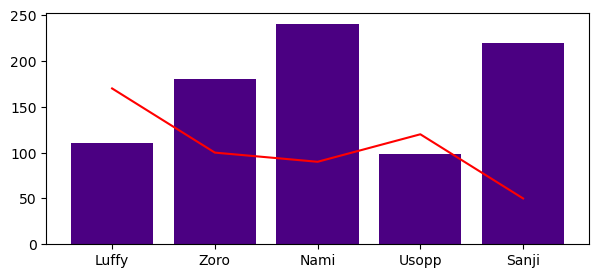

In [49]:
##We can plot multiple plot elements/visuals on the same axes object
##just call one of our plot methods (e.g. bar, scatter, etc) on the same axes

##first make our sample data
x = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])
y2 = np.array([170, 100, 90, 120, 50])

##define our figure and axes (just one this time)
fig, ax = plt.subplots(figsize=(7, 3))

##now call both bar and plot elements to the same axes (ax)
ax.bar(x, y1,
      color = "indigo")
ax.plot(x, y2,
       color = "red")

##other elements like annotations, shapes, etc, can be layered as we did previously

##  Add Error Information

<ErrorbarContainer object of 3 artists>

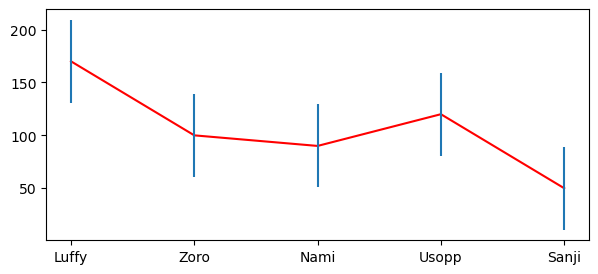

In [50]:
##First we want to calculate standard deviation of our data (how much it's dispersed)
y2_sd = np.std(y2)

##plot our figure as before
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2,
       color = "red")

##but this time we use errorbar() to add our error
ax.errorbar(x, #our x values
            y2, #our y values
           yerr = y2_sd, #the error value at each pt (std deviation)
           fmt = "none") #make sure we're not plotting the actual data points, only the error

<ErrorbarContainer object of 3 artists>

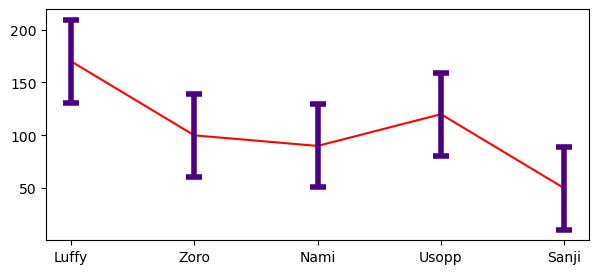

In [34]:
##We can also customize the appearance of our errorbars
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2,
       color = "red")

ax.errorbar(x,
            y2,
           yerr = y2_sd,
           fmt = "none",
           ecolor = "indigo",
           elinewidth = 4,
           capsize = 6, 
           capthick = 4)

<ErrorbarContainer object of 3 artists>

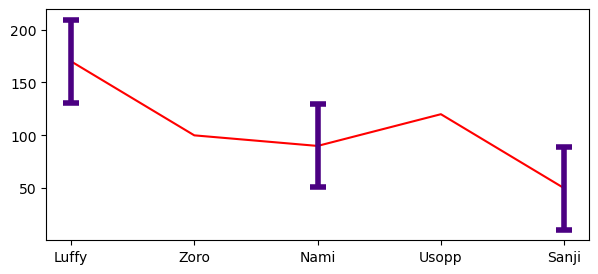

In [35]:
##if we don't want to see error bars for every point, we can use errorevery

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2,
       color = "red")

ax.errorbar(x,
            y2,
           yerr = y2_sd,
           fmt = "none",
           ecolor = "indigo",
           elinewidth = 4,
           capsize = 6, 
           capthick = 4,
           errorevery = 2) #only show error bars every other point

## Add images to plots

In [52]:
##first let's get our image

##load libraries (that we haven't already)
##if you haven't installed PIL pip install Pillow
from PIL import Image ##to open images
import requests ##to get images from URLs
from io import BytesIO ##to store images

##now get our image from the internet
response = requests.get('https://upload.wikimedia.org/wikipedia/en/c/cb/Monkey_D_Luffy.png')
image_file = BytesIO(response.content)
image = Image.open(image_file)


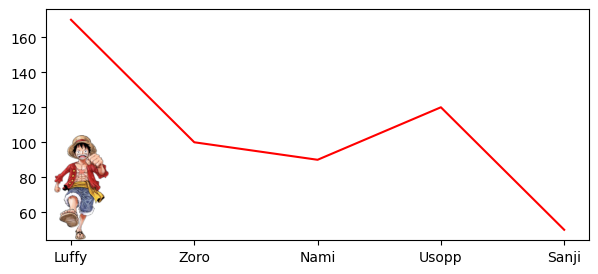

In [54]:
## now let's remake our plot 
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2,
       color = "red")

##add an axes to our figure
##this axes will be overlaid on our existing axes ('ax') and will act as a container for our image
ax_image = fig.add_axes([0.1, ##x coordinate (ON FIGURE, NOT AXES)
                         0.11, ##y coordinate (ON FIGURE, NOT AXES)
                         0.15, ##image width
                         0.35] ##image height
                       )

##now use imshow() to add our image we prepped before
ax_image.imshow(image)
ax_image.axis('off')  # Remove axis ticks/labels of the image (since we just created another axes)

plt.show()

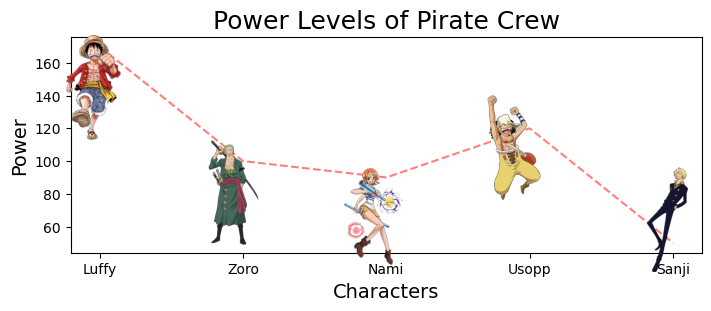

In [121]:
## let's make a real fancy plot for fun

##collect our images for each datapoint
response = requests.get('https://upload.wikimedia.org/wikipedia/en/c/cb/Monkey_D_Luffy.png')
image_file = BytesIO(response.content)
luffyimg = Image.open(image_file)

response = requests.get('https://static.wikia.nocookie.net/p__/images/6/6e/Roronoa_Zoro_Post_Timeskip.png/revision/latest?cb=20190529044836&path-prefix=protagonist')
image_file = BytesIO(response.content)
zoroimg = Image.open(image_file)

response = requests.get('https://static.wikia.nocookie.net/p__/images/f/f0/Nami_Waifuuu.png/revision/latest?cb=20190113023031&path-prefix=protagonist')
image_file = BytesIO(response.content)
namiimg = Image.open(image_file)

response = requests.get('https://static.wikia.nocookie.net/p__/images/5/53/Usopp.png/revision/latest?cb=20190529045324&path-prefix=protagonist')
image_file = BytesIO(response.content)
usoppimg = Image.open(image_file)

response = requests.get('https://static.wikia.nocookie.net/p__/images/b/b0/Sanji_Vector.png/revision/latest?cb=20190426102221&path-prefix=protagonist')
image_file = BytesIO(response.content)
sanjiimg = Image.open(image_file)

##remake our plot 
fig, ax = plt.subplots(figsize=(7, 3),
                      layout = "constrained")
ax.plot(x, y2,
       color = "red",
       alpha = 0.5,
       linestyle = '--')

##add axes containers for each image
ax_luf = fig.add_axes([0.05, ##x coordinate (ON FIGURE, NOT AXES)
                         0.55, ##y coordinate (ON FIGURE, NOT AXES)
                         0.15, ##image width
                         0.35] ##image height
                       )

ax_zoro = fig.add_axes([0.25, ##x coordinate (ON FIGURE, NOT AXES)
                         0.2, ##y coordinate (ON FIGURE, NOT AXES)
                         0.15, ##image width
                         0.35] ##image height
                       )

ax_nami = fig.add_axes([0.45, ##x coordinate (ON FIGURE, NOT AXES)
                         0.12, ##y coordinate (ON FIGURE, NOT AXES)
                         0.15, ##image width
                         0.35] ##image height
                       )


ax_usopp = fig.add_axes([0.65, ##x coordinate (ON FIGURE, NOT AXES)
                         0.35, ##y coordinate (ON FIGURE, NOT AXES)
                         0.15, ##image width
                         0.35] ##image height
                       )

ax_sanji = fig.add_axes([0.87, ##x coordinate (ON FIGURE, NOT AXES)
                         0.11, ##y coordinate (ON FIGURE, NOT AXES)
                         0.15, ##image width
                         0.35] ##image height
                       )

##now use imshow() to add our images we prepped before
ax_luf.imshow(luffyimg)
ax_luf.axis('off')  

ax_zoro.imshow(zoroimg)
ax_zoro.axis('off')

ax_nami.imshow(namiimg)
ax_nami.axis('off')

ax_usopp.imshow(usoppimg)
ax_usopp.axis('off')

ax_sanji.imshow(sanjiimg)
ax_sanji.axis('off')


##now add labels and titles to our plot
ax.set_xlabel('Characters', fontsize = 14)
ax.set_ylabel('Power', fontsize = 14)
ax.set_title('Power Levels of Pirate Crew', fontsize = 18)
           
##show plot
plt.show()
